# STATISTICAL ANALYSIS

## Load the data
- Here I load the pickle file that was saved in step1

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# We load the pickle file so we have the correct data type

df = pd.read_pickle('data_MPG_clean.pkl')

In [3]:
# print 10 sample values

print(df.sample(10))

           mpg  cylinders  displacement  horsepower  weight  acceleration  \
283  20.203125          6           232          90    3265     18.203125   
286  17.593750          8           302         129    3725     13.398438   
322  46.593750          4            86          65    2110     17.906250   
387  38.000000          6           262          85    3015     17.000000   
307  26.796875          6           173         115    2700     12.898438   
231  15.500000          8           400         190    4325     12.203125   
341  23.500000          6           173         110    2725     12.601562   
175  29.000000          4            90          70    1937     14.000000   
201  18.500000          6           250         110    3645     16.203125   
305  28.406250          4           151          90    2670     16.000000   

     model_year  origin  
283          79     usa  
286          79     usa  
322          80   japan  
387          82     usa  
307          79     us

In [4]:
# lets see data types and memory usage

print(df.info(memory_usage="deep"))

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           392 non-null    float16 
 1   cylinders     392 non-null    int8    
 2   displacement  392 non-null    int16   
 3   horsepower    392 non-null    int16   
 4   weight        392 non-null    int16   
 5   acceleration  392 non-null    float16 
 6   model_year    392 non-null    int8    
 7   origin        392 non-null    category
dtypes: category(1), float16(2), int16(3), int8(2)
memory usage: 8.2 KB
None


# Add Variability (Mean + Std)

In [6]:
# TODO: Remove warning
# step1: Display mean, std_dev, count for cars MPG by origin

df.groupby('origin')['mpg'].agg(['mean', 'std', 'count'])

C:\Users\hi\AppData\Local\Temp\ipykernel_9212\214525410.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('origin')['mpg'].agg(['mean', 'std', 'count'])


,mean,std,count
origin,,,
europe,27.603630,6.581332,68
japan,30.450159,6.089157,79
usa,20.033354,6.440096,245


# Visual Support (Mean ± Variability)

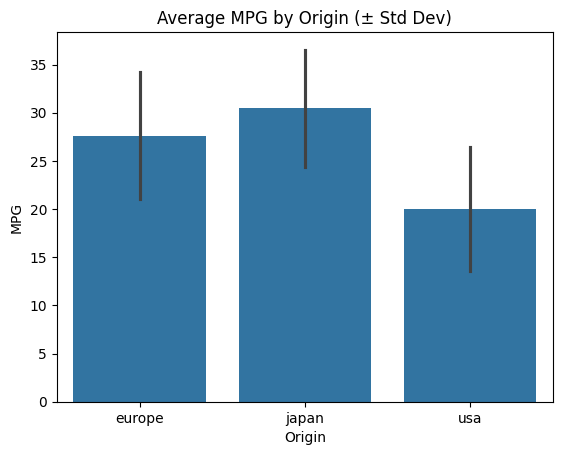

In [7]:
# step2: Show me the visual
sns.barplot(
    data=df,
    x="origin",
    y="mpg",
    errorbar="sd"
)

plt.title("Average MPG by Origin (± Std Dev)")
plt.ylabel("MPG")
plt.xlabel("Origin")
plt.show()

# observ: Japanese cars have high mean MPG.
# The variability , AKA STD_dev, is same for all 3 cars

# Hypothesis Testing: One-Way ANOVA

### Question:

Is the difference in average MPG across origins statistically significant?


### Hypotheses
- H₀ (Null): Mean MPG is the same for all origins
- H₁ (Alt): At least one origin has a different mean MPG

In [10]:
# step1
from scipy.stats import f_oneway

usa = df[df['origin'] == 'usa']['mpg']
europe = df[df['origin'] == 'europe']['mpg']
japan = df[df['origin'] == 'japan']['mpg']
# print(usa)

f_stat, p_value = f_oneway(usa, europe, japan)

print(f_stat, p_value)

0      18.0
1      15.0
2      18.0
3      16.0
4      17.0
       ... 
392    27.0
393    27.0
395    32.0
396    28.0
397    31.0
Name: mpg, Length: 245, dtype: float16
96.60669271682914 8.643951050960421e-35


In [9]:
# step2

if p_value < 0.05:
    print("Reject H₀: MPG differs significantly across origins")
else:
    print("Fail to reject H₀: No significant difference in MPG")


Reject H₀: MPG differs significantly across origins
